In [1]:
import requests
import pandas as pd

APIS = {
    'NOC' : 'https://linkedsystems.uk/sensorthings/v1.1/',
    'BGS' : 'https://sensors.bgs.ac.uk/FROST-Server/v1.1/'
}

def getObsByDatastream(api,id):
    # Step 1: Define the API endpoint
    
    url = APIS[api] + f'Datastreams({id})/Observations?$orderby=phenomenonTime%20desc'
    
    # Step 2: Make a GET request to the API
    response = requests.get(url)
    
    # Step 3: Convert the JSON response to a Python list of dictionaries
    data = response.json()['value']
    
    # Step 4: Load the data into a Pandas DataFrame
    return pd.DataFrame(data)

df = getObsByDatastream('BGS',23)
    

In [2]:
df.head()

,@iot.selfLink,@iot.id,phenomenonTime,resultTime,result,resultQuality,parameters,Datastream@iot.navigationLink,FeatureOfInterest@iot.navigationLink
0,https://sensors.bgs.ac.uk/FROST-Server/v1.1/Ob...,378354032,2025-01-08T13:00:00Z,2025-01-08T13:00:00Z,3.38,"{'reason': 'Data Verified (manual check)', 'st...","{'publish_yn': 'Y', 'sen_id': 378354032}",https://sensors.bgs.ac.uk/FROST-Server/v1.1/Ob...,https://sensors.bgs.ac.uk/FROST-Server/v1.1/Ob...
1,https://sensors.bgs.ac.uk/FROST-Server/v1.1/Ob...,378363188,2025-01-08T12:45:00Z,2025-01-08T12:45:00Z,3.31,"{'reason': 'Data Verified (manual check)', 'st...","{'publish_yn': 'Y', 'sen_id': 378363188}",https://sensors.bgs.ac.uk/FROST-Server/v1.1/Ob...,https://sensors.bgs.ac.uk/FROST-Server/v1.1/Ob...
2,https://sensors.bgs.ac.uk/FROST-Server/v1.1/Ob...,378365527,2025-01-08T12:30:00Z,2025-01-08T12:30:00Z,3.38,"{'reason': 'Data Verified (manual check)', 'st...","{'publish_yn': 'Y', 'sen_id': 378365527}",https://sensors.bgs.ac.uk/FROST-Server/v1.1/Ob...,https://sensors.bgs.ac.uk/FROST-Server/v1.1/Ob...
3,https://sensors.bgs.ac.uk/FROST-Server/v1.1/Ob...,378367864,2025-01-08T12:15:00Z,2025-01-08T12:15:00Z,3.44,"{'reason': 'Data Verified (manual check)', 'st...","{'publish_yn': 'Y', 'sen_id': 378367864}",https://sensors.bgs.ac.uk/FROST-Server/v1.1/Ob...,https://sensors.bgs.ac.uk/FROST-Server/v1.1/Ob...
4,https://sensors.bgs.ac.uk/FROST-Server/v1.1/Ob...,378354031,2025-01-08T12:00:00Z,2025-01-08T12:00:00Z,3.50,"{'reason': 'Data Verified (manual check)', 'st...","{'publish_yn': 'Y', 'sen_id': 378354031}",https://sensors.bgs.ac.uk/FROST-Server/v1.1/Ob...,https://sensors.bgs.ac.uk/FROST-Server/v1.1/Ob...


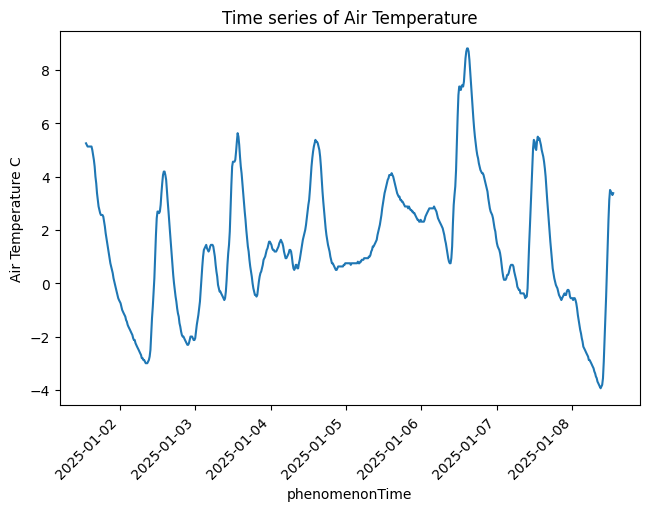

In [3]:
# Basic plot

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# covnert str datetimes to datetime
df['phenomenonTime'] = pd.to_datetime(df['phenomenonTime'], errors='coerce')

fig, ax = plt.subplots()
ax.plot(df.phenomenonTime, df.result, marker='', linestyle='-')


ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.xticks(rotation=45, ha='right')

# Adjust layout to prevent clipping
plt.tight_layout()

plt.xlabel('phenomenonTime')
plt.ylabel('Air Temperature C')
plt.title('Time series of Air Temperature')

plt.show()

In [4]:
# Interactive plot

%matplotlib widget
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from ipywidgets import interact

# Ensure datetime conversion
df['phenomenonTime'] = pd.to_datetime(df['phenomenonTime'], errors='coerce')

@interact
def plot():
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(df['phenomenonTime'], df['result'], linestyle='-')

    locator = mdates.AutoDateLocator()
    formatter = mdates.ConciseDateFormatter(locator)

    formatter.formats = [
        '%Y-%m-%d',  # years
        '%Y-%m-%d',  # months
        '%Y-%m-%d',  # days
        '%H:%M',     # hours
        '%H:%M',     # minutes
        '%H:%M:%S'   # seconds
    ]

    formatter.zero_formats = [
        '%Y-%m-%d',  # years
        '%Y-%m-%d',  # months
        '%Y-%m-%d',  # days
        '%Y-%m-%d',  # hours → ensures midnight shows full date
        '', '', ''   # minutes, seconds
    ]

    formatter.offset_formats = [''] * 6

    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)

    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    plt.xlabel('phenomenonTime')
    plt.ylabel('Air Temperature C')
    plt.title('Time series of Air Temperature')
    fig.subplots_adjust(top=0.9, bottom=0.2, left=0.15, right=0.95)

    plt.show()


interactive(children=(Output(),), _dom_classes=('widget-interact',))

In [5]:
# function to get all datastreams by observed property definition

def getDatastreamsByProperty(definition):
    datastreams = pd.DataFrame()
    for api in APIS.keys():
        api_root = APIS[api]
        
        url = api_root + f'Datastreams?$filter=ObservedProperty/definition%20eq%20%27{definition}%27&$select=id,name&$expand=Thing($select=name)'
        print(url)
        response = requests.get(url)
        data = response.json()['value']
        df = pd.DataFrame(data)
        df['api'] = api
        datastreams = pd.concat([datastreams, df], ignore_index=True)
        
    name_to_url = {
        datastream['Thing']['name'] + ' ' + datastream['name']: APIS[datastream['api']] + 'Datastreams(' + str(int(datastream['@iot.id'])) + ')'
        for _, datastream in datastreams.iterrows()
     }

    return name_to_url

getDatastreamsByProperty('http://vocab.nerc.ac.uk/collection/P07/current/CFSN0023/')

https://linkedsystems.uk/sensorthings/v1.1/Datastreams?$filter=ObservedProperty/definition%20eq%20%27http://vocab.nerc.ac.uk/collection/P07/current/CFSN0023/%27&$select=id,name&$expand=Thing($select=name)
https://sensors.bgs.ac.uk/FROST-Server/v1.1/Datastreams?$filter=ObservedProperty/definition%20eq%20%27http://vocab.nerc.ac.uk/collection/P07/current/CFSN0023/%27&$select=id,name&$expand=Thing($select=name)


{'Atmospheric Measurement & Observation Facility Air Temperature': 'https://linkedsystems.uk/sensorthings/v1.1/Datastreams(1)',
 'RRS Discovery Meteorology Platform Air Temperature': 'https://linkedsystems.uk/sensorthings/v1.1/Datastreams(2)',
 'RRS Sir David Attenborough Meteorology Platform Air Temperature': 'https://linkedsystems.uk/sensorthings/v1.1/Datastreams(3)',
 'RRS James Cook Meteorology Platform Air_Temperature': 'https://linkedsystems.uk/sensorthings/v1.1/Datastreams(4)',
 'BGS GGERFS Barometer GGERFS_01 Air Temperature': 'https://sensors.bgs.ac.uk/FROST-Server/v1.1/Datastreams(23)'}

In [6]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, widgets
import requests

@interact
def hello(AirTempThings = getDatastreamsByProperty('http://vocab.nerc.ac.uk/collection/P07/current/CFSN0023/')):
    plt.show()

https://linkedsystems.uk/sensorthings/v1.1/Datastreams?$filter=ObservedProperty/definition%20eq%20%27http://vocab.nerc.ac.uk/collection/P07/current/CFSN0023/%27&$select=id,name&$expand=Thing($select=name)
https://sensors.bgs.ac.uk/FROST-Server/v1.1/Datastreams?$filter=ObservedProperty/definition%20eq%20%27http://vocab.nerc.ac.uk/collection/P07/current/CFSN0023/%27&$select=id,name&$expand=Thing($select=name)


interactive(children=(Dropdown(description='AirTempThings', options={'Atmospheric Measurement & Observation Fa…

In [7]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, widgets
import requests

AirTempDatastreams = getDatastreamsByProperty('http://vocab.nerc.ac.uk/collection/P07/current/CFSN0023/')

@interact
def hello(Datastream = AirTempDatastreams):
    print(Datastream)
    # Getting the observations
    response = requests.get(Datastream +'/Observations?$orderby=phenomenonTime%20desc')
    
    # Step 3: Convert the JSON response to a Python list of dictionaries
    data = response.json()['value']

    if len(data) > 0 :
    
        # Step 4: Load the data into a Pandas DataFrame
        df =  pd.DataFrame(data)
    
        
        # Convert 'result' to numeric, setting non-numeric values to NaN
        df['result'] = pd.to_numeric(df['result'], errors='coerce')
        
        # Drop rows where 'result' is NaN (i.e., was not a number)
        df = df.dropna(subset=['result'])

        print(df.dtypes)
        df['phenomenonTime'] = pd.to_datetime(df['phenomenonTime'], utc=True)
        
        #plot
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.plot(df['phenomenonTime'], df['result'], linestyle='-')
    
        locator = mdates.AutoDateLocator()
        formatter = mdates.ConciseDateFormatter(locator)
    
        formatter.formats = [
            '%Y-%m-%d',  # years
            '%Y-%m-%d',  # months
            '%Y-%m-%d',  # days
            '%Y-%m-%d %H:%M',     # hours
            '%Y-%m-%d %H:%M',     # minutes
            '%Y-%m-%d %H:%M:%S'   # seconds
        ]
    
        formatter.zero_formats = [
            '%Y-%m-%d',  # years
            '%Y-%m-%d',  # months
            '%Y-%m-%d',  # days
            '%Y-%m-%d %H:%M',     # hours
            '%Y-%m-%d %H:%M',     # minutes
            '%Y-%m-%d %H:%M:%S'   # seconds
        ]
    
        formatter.offset_formats = [''] * 6
    
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_major_formatter(formatter)
    
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
    
        plt.xlabel('phenomenonTime')
        plt.ylabel('Air Temperature C')
        plt.title('Time series of Air Temperature')
        fig.subplots_adjust(top=0.9, bottom=0.2, left=0.15, right=0.95)
    
        plt.show()
    else:
        print('There are no observations yet for this datastream')

https://linkedsystems.uk/sensorthings/v1.1/Datastreams?$filter=ObservedProperty/definition%20eq%20%27http://vocab.nerc.ac.uk/collection/P07/current/CFSN0023/%27&$select=id,name&$expand=Thing($select=name)
https://sensors.bgs.ac.uk/FROST-Server/v1.1/Datastreams?$filter=ObservedProperty/definition%20eq%20%27http://vocab.nerc.ac.uk/collection/P07/current/CFSN0023/%27&$select=id,name&$expand=Thing($select=name)


interactive(children=(Dropdown(description='Datastream', options={'Atmospheric Measurement & Observation Facil…

In [8]:
# next may be to get distinct lsit of property definitions an dallow ddrop down

In [9]:
url = 'https://linkedsystems.uk/sensorthings/v1.1/Things(1)/HistoricalLocations?$expand=Locations&$orderby=time'
# Getting the observations
response = requests.get(url)

# Step 3: Convert the JSON response to a Python list of dictionaries
data = response.json()['value']

# Step 4: Load the data into a Pandas DataFrame
df =  pd.DataFrame(data)

In [10]:
df

,@iot.selfLink,@iot.id,time,Locations,Thing@iot.navigationLink,Locations@iot.navigationLink
0,https://linkedsystems.uk/sensorthings/v1.1/His...,1,2025-10-02T11:02:12.962Z,[{'@iot.selfLink': 'https://linkedsystems.uk/s...,https://linkedsystems.uk/sensorthings/v1.1/His...,https://linkedsystems.uk/sensorthings/v1.1/His...


In [11]:
# function to get all things by observed property definition, with location history 

def getThingsByProperty(definition):
    things = pd.DataFrame()
    for api in APIS.keys():
        api_root = APIS[api]
        
        url = api_root + f'Things?$filter=Datastreams/ObservedProperty/definition%20eq%20%27{definition}%27&$select=id,name&$expand=HistoricalLocations($orderby=time;$select=time;$expand=Locations)'
        print(url)
        response = requests.get(url)
        data = response.json()['value']
        df = pd.DataFrame(data)
        df['api'] = api
        things = pd.concat([things, df], ignore_index=True)
        
    name_to_url = {
        thing['name']: APIS[thing['api']] + 'Things(' + str(int(thing['@iot.id'])) + ')'
        for _, thing in things.iterrows()
     }

    return name_to_url

getThingsByProperty('http://vocab.nerc.ac.uk/collection/P07/current/CFSN0023/')

https://linkedsystems.uk/sensorthings/v1.1/Things?$filter=Datastreams/ObservedProperty/definition%20eq%20%27http://vocab.nerc.ac.uk/collection/P07/current/CFSN0023/%27&$select=id,name&$expand=HistoricalLocations($orderby=time;$select=time;$expand=Locations)
https://sensors.bgs.ac.uk/FROST-Server/v1.1/Things?$filter=Datastreams/ObservedProperty/definition%20eq%20%27http://vocab.nerc.ac.uk/collection/P07/current/CFSN0023/%27&$select=id,name&$expand=HistoricalLocations($orderby=time;$select=time;$expand=Locations)


{'Atmospheric Measurement & Observation Facility': 'https://linkedsystems.uk/sensorthings/v1.1/Things(1)',
 'RRS Discovery Meteorology Platform': 'https://linkedsystems.uk/sensorthings/v1.1/Things(2)',
 'RRS Sir David Attenborough Meteorology Platform': 'https://linkedsystems.uk/sensorthings/v1.1/Things(3)',
 'RRS James Cook Meteorology Platform': 'https://linkedsystems.uk/sensorthings/v1.1/Things(4)',
 'BGS GGERFS Barometer': 'https://sensors.bgs.ac.uk/FROST-Server/v1.1/Things(8)'}

In [12]:
from ipyleaflet import Map, Polyline, Marker, Popup, LayerGroup
from ipywidgets import HTML, Dropdown, VBox
import requests
import pandas as pd

# Create a persistent map object
initial_thing = 'https://linkedsystems.uk/sensorthings/v1.1/Things(1)'
m = Map(center=(52.9, -1.1), zoom=10)
layer_group = LayerGroup()
m.add_layer(layer_group)

def getMapLayersForThing(Thing):
    url = f'{Thing}/HistoricalLocations?$expand=Locations&$orderby=time desc'
    response = requests.get(url)
    data = response.json()['value']
    df = pd.DataFrame(data)

    locations = []
    layers = []

    for l in df['Locations']:
        if len(l) > 0:
            location = l[0]['location']['coordinates']
            if len(location) == 2:
                locations.append((location[1], location[0]))  # (lat, lon)

    # Add polyline
    if locations:
        line = Polyline(locations=locations, color="blue", fill=False)
        layers.append(line)

    # Add markers with popups
    for _, row in df.iterrows():
        if len(row['Locations']) > 0:
            coords = row['Locations'][0]['location']['coordinates']
            if len(coords) == 2:
                location = (coords[1], coords[0])
                info = f"{row['time']} - {row['Locations'][0]['name']}"
                html = HTML(value=f"<b>{info}</b>")
                popup = Popup(child=html, close_button=False, auto_close=False, close_on_escape=False)
                marker = Marker(location=location, popup=popup)
                layers.append(marker)

    return locations[0] if locations else (52.9, -1.1), layers

# Dropdown setup
things = getThingsByProperty('http://vocab.nerc.ac.uk/collection/P07/current/CFSN0023/')
dropdown = Dropdown(options=things)

def on_dropdown_change(change):
    if change["name"] == "value":
        center, new_layers = getMapLayersForThing(change["new"])
        m.center = center
        layer_group.clear_layers()
        for layer in new_layers:
            layer_group.add_layer(layer)

dropdown.observe(on_dropdown_change, names="value")

# Initial map setup
center, initial_layers = getMapLayersForThing(initial_thing)
m.center = center
for layer in initial_layers:
    layer_group.add_layer(layer)

VBox([dropdown, m])

https://linkedsystems.uk/sensorthings/v1.1/Things?$filter=Datastreams/ObservedProperty/definition%20eq%20%27http://vocab.nerc.ac.uk/collection/P07/current/CFSN0023/%27&$select=id,name&$expand=HistoricalLocations($orderby=time;$select=time;$expand=Locations)
https://sensors.bgs.ac.uk/FROST-Server/v1.1/Things?$filter=Datastreams/ObservedProperty/definition%20eq%20%27http://vocab.nerc.ac.uk/collection/P07/current/CFSN0023/%27&$select=id,name&$expand=HistoricalLocations($orderby=time;$select=time;$expand=Locations)


#hello

In [13]:
from ipyleaflet import Map, Polyline, Marker, Popup, LayerGroup
from ipywidgets import HTML, Dropdown, VBox
import requests
import pandas as pd

def getAllLocations():
    locations = pd.DataFrame()
    for api in APIS.keys():
        api_root = APIS[api]
        
        url = api_root + f'Locations?$filter=ObservedProperty/definition%20eq%20%27{definition}%27&$select=id,name&$expand=Thing($select=name)'
        print(url)
        response = requests.get(url)
        data = response.json()['value']
        df = pd.DataFrame(data)
        df['api'] = api
        datastreams = pd.concat([datastreams, df], ignore_index=True)
        
    name_to_url = {
        datastream['Thing']['name'] + ' ' + datastream['name']: APIS[datastream['api']] + 'Datastreams(' + str(int(datastream['@iot.id'])) + ')'
        for _, datastream in datastreams.iterrows()
     }

    return name_to_url
    

# Create a persistent map object
initial_thing = 'https://linkedsystems.uk/sensorthings/v1.1/Things(1)'
m = Map(center=(52.9, -1.1), zoom=10)
layer_group = LayerGroup()
m.add_layer(layer_group)

def getMapLayersForThing(Thing):
    url = f'{Thing}/HistoricalLocations?$expand=Locations&$orderby=time desc'
    response = requests.get(url)
    data = response.json()['value']
    df = pd.DataFrame(data)

    locations = []
    layers = []

    for l in df['Locations']:
        if len(l) > 0:
            location = l[0]['location']['coordinates']
            if len(location) == 2:
                locations.append((location[1], location[0]))  # (lat, lon)

    # Add polyline
    if locations:
        line = Polyline(locations=locations, color="blue", fill=False)
        layers.append(line)

    # Add markers with popups
    for _, row in df.iterrows():
        if len(row['Locations']) > 0:
            coords = row['Locations'][0]['location']['coordinates']
            if len(coords) == 2:
                location = (coords[1], coords[0])
                info = f"{row['time']} - {row['Locations'][0]['name']}"
                html = HTML(value=f"<b>{info}</b>")
                popup = Popup(child=html, close_button=False, auto_close=False, close_on_escape=False)
                marker = Marker(location=location, popup=popup)
                layers.append(marker)

    return locations[0] if locations else (52.9, -1.1), layers

# Dropdown setup
things = getThingsByProperty('http://vocab.nerc.ac.uk/collection/P07/current/CFSN0023/')
dropdown = Dropdown(options=things)

def on_dropdown_change(change):
    if change["name"] == "value":
        center, new_layers = getMapLayersForThing(change["new"])
        m.center = center
        layer_group.clear_layers()
        for layer in new_layers:
            layer_group.add_layer(layer)

dropdown.observe(on_dropdown_change, names="value")

# Initial map setup
center, initial_layers = getMapLayersForThing(initial_thing)
m.center = center
for layer in initial_layers:
    layer_group.add_layer(layer)

VBox([dropdown, m])

https://linkedsystems.uk/sensorthings/v1.1/Things?$filter=Datastreams/ObservedProperty/definition%20eq%20%27http://vocab.nerc.ac.uk/collection/P07/current/CFSN0023/%27&$select=id,name&$expand=HistoricalLocations($orderby=time;$select=time;$expand=Locations)
https://sensors.bgs.ac.uk/FROST-Server/v1.1/Things?$filter=Datastreams/ObservedProperty/definition%20eq%20%27http://vocab.nerc.ac.uk/collection/P07/current/CFSN0023/%27&$select=id,name&$expand=HistoricalLocations($orderby=time;$select=time;$expand=Locations)
